# Bayesian Multinomial Logit with Pyro

In [ ]:
import pandas as pd
import numpy as np
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import seaborn as sns


# Set seeds for reproducibility
np.random.seed(11)
torch.manual_seed(11)
pyro.set_rng_seed(11)

/Users/imara/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/1. COURSES/294746 - Model Based Machine Learning/Project/mbml_project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load and explore data

In [2]:
df = pd.read_csv('swissmetro.dat', sep='\t')
print(df.head())
print(df.shape)

# Keep only observations with known age, explicit choices, and non-'other' trip purposes.
# In this file, AGE==6 is the unknown age code and PURPOSE==9 is 'other'.
valid_age = df['AGE'].notna() & (df['AGE'] != 6)
valid_choice = df['CHOICE'] != 0
valid_purpose = df['PURPOSE'] != 9
df = df[valid_age & valid_choice & valid_purpose].copy()

print(f"After filtering: {df.shape[0]} rows, {df['ID'].nunique()} respondents")

# Select a random subset of 50 IDs
selected_ids = df['ID'].drop_duplicates().sample(n=50)

# Filter the dataset to include only rows with the selected IDs
df = df[df['ID'].isin(selected_ids)].copy()

print(f"With 50 IDs: {df.shape[0]} rows")
print(f"Columns: {df.columns.tolist()}")


   GROUP  SURVEY  SP  ID  PURPOSE  FIRST  TICKET  WHO  LUGGAGE  AGE  ...  \
0      2       0   1   1        1      0       1    1        0    3  ...   
1      2       0   1   1        1      0       1    1        0    3  ...   
2      2       0   1   1        1      0       1    1        0    3  ...   
3      2       0   1   1        1      0       1    1        0    3  ...   
4      2       0   1   1        1      0       1    1        0    3  ...   

   TRAIN_TT  TRAIN_CO  TRAIN_HE  SM_TT  SM_CO  SM_HE  SM_SEATS  CAR_TT  \
0       112        48       120     63     52     20         0     117   
1       103        48        30     60     49     10         0     117   
2       130        48        60     67     58     30         0     117   
3       103        40        30     63     52     20         0      72   
4       130        36        60     63     42     20         0      90   

   CAR_CO  CHOICE  
0      65       2  
1      84       2  
2      52       2  
3      52       2 

In [3]:
# Check available modes and choice distribution
print(f"Unique choices: {sorted(df['CHOICE'].unique())}")
print(f"\nChoice distribution:\n{df['CHOICE'].value_counts().sort_index()}")
print(f"\nMode availability:")
print(f"TRAIN_AV: {df['TRAIN_AV'].sum()} / {len(df)}")
print(f"SM_AV: {df['SM_AV'].sum()} / {len(df)}")
print(f"CAR_AV: {df['CAR_AV'].sum()} / {len(df)}")

Unique choices: [np.int64(1), np.int64(2), np.int64(3)]

Choice distribution:
CHOICE
1     76
2    275
3     99
Name: count, dtype: int64

Mode availability:
TRAIN_AV: 450 / 450
SM_AV: 450 / 450
CAR_AV: 342 / 450


### Prepare data for choice model

Transform to long format (one row per alternative per decision) for the discrete choice model.

In [4]:
# We'll work with travel time and cost
# Modes: 1=Train, 2=SwissMetro, 3=Car

# Standardize attributes (z-score: (x - mean) / std)
df['TRAIN_TT_SCALED'] = (df['TRAIN_TT'] - df['TRAIN_TT'].mean()) / df['TRAIN_TT'].std()
df['TRAIN_CO_SCALED'] = (df['TRAIN_CO'] - df['TRAIN_CO'].mean()) / df['TRAIN_CO'].std()
df['SM_TT_SCALED'] = (df['SM_TT'] - df['SM_TT'].mean()) / df['SM_TT'].std()
df['SM_CO_SCALED'] = (df['SM_CO'] - df['SM_CO'].mean()) / df['SM_CO'].std()
df['CAR_TT_SCALED'] = (df['CAR_TT'] - df['CAR_TT'].mean()) / df['CAR_TT'].std()
df['CAR_CO_SCALED'] = (df['CAR_CO'] - df['CAR_CO'].mean()) / df['CAR_CO'].std()

print(f"Standardized data (mean≈0, std≈1):\n{df[['TRAIN_TT_SCALED', 'TRAIN_CO_SCALED', 'SM_TT_SCALED', 'SM_CO_SCALED', 'CHOICE']].head(10)}")


Standardized data (mean≈0, std≈1):
     TRAIN_TT_SCALED  TRAIN_CO_SCALED  SM_TT_SCALED  SM_CO_SCALED  CHOICE
279         1.675831        -0.470165      0.795171     -0.465563       2
280         1.675831        -0.470165      0.561389     -0.454230       1
281         1.675831        -0.473971      0.374363     -0.454230       2
282         0.775591        -0.473971      0.374363     -0.454230       2
283         1.080288        -0.470165      0.374363     -0.462730       2
284         1.080288        -0.473971      0.561389     -0.465563       2
285         1.080288        -0.462553      0.374363     -0.465563       2
286         1.675831        -0.462553      0.561389     -0.462730       2
287         1.080288        -0.470165      0.561389     -0.454230       2
378        -1.038738         1.866706     -1.285490      1.415662       2


### Convert to long format

In [5]:
# Create long-format data for MNL estimation
# Each row observation becomes 3 rows (one per alternative that is available)

long_data = []

# Create a mapping from original indices to sequential obs_id (0, 1, 2, ...)
obs_id_map = {orig_idx: new_idx for new_idx, orig_idx in enumerate(df.index.unique())}

for idx, row in df.iterrows():
    obs_id_sequential = obs_id_map[idx]  # Map to sequential ID
    original_id = row['ID']  # Keep track of the individual ID
    
    # Train (alt_id 0)
    if row['TRAIN_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 0,
            'tt': row['TRAIN_TT_SCALED'],
            'co': row['TRAIN_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 1 else 0
        })
    
    # SwissMetro (alt_id 1)
    if row['SM_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 1,
            'tt': row['SM_TT_SCALED'],
            'co': row['SM_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 2 else 0
        })
    
    # Car (alt_id 2)
    if row['CAR_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 2,
            'tt': row['CAR_TT_SCALED'],
            'co': row['CAR_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 3 else 0
        })

long_df = pd.DataFrame(long_data)

# Validate: exactly one choice per obs_id
choices_per_obs = long_df.groupby('obs_id')['choice'].sum()
assert (choices_per_obs == 1).all(), "Error: some observations have != 1 choice"
print("✓ Validation passed: exactly one choice per observation")

print(f"\nLong format shape: {long_df.shape}")
print(f"Number of unique observations: {long_df['obs_id'].nunique()}")
print(f"Number of unique individuals: {long_df['ID'].nunique()}")
print(f"Obs_id range: [{long_df['obs_id'].min()}, {long_df['obs_id'].max()}]")
print(f"\nSample (first 9 rows = 3 obs):")
long_df.head(9)


✓ Validation passed: exactly one choice per observation

Long format shape: (1242, 6)
Number of unique observations: 450
Number of unique individuals: 50
Obs_id range: [0, 449]

Sample (first 9 rows = 3 obs):


,obs_id,ID,alt_id,tt,co,choice
0,0,32.0,0,1.675831,-0.470165,0
1,0,32.0,1,0.795171,-0.465563,1
2,1,32.0,0,1.675831,-0.470165,1
3,1,32.0,1,0.561389,-0.454230,0
4,2,32.0,0,1.675831,-0.473971,0
5,2,32.0,1,0.374363,-0.454230,1
6,3,32.0,0,0.775591,-0.473971,0
7,3,32.0,1,0.374363,-0.454230,1
8,4,32.0,0,1.080288,-0.470165,0


In [6]:
# Convert to PyTorch tensors for Pyro
X = torch.tensor(long_df[['tt', 'co']].values, dtype=torch.float32)
Y = torch.tensor(long_df['choice'].values, dtype=torch.int64)
obs_id = torch.tensor(long_df['obs_id'].values, dtype=torch.int64)
alt_id = torch.tensor(long_df['alt_id'].values, dtype=torch.int64)

# Verify tensors are built from the already-filtered dataframe.
assert long_df['obs_id'].nunique() == len(df), "Tensor basis check failed: long_df/df observation mismatch."
print(f"Tensor basis check passed: {len(df)} filtered scenarios -> {len(long_df)} long-format rows")

Tensor basis check passed: 450 filtered scenarios -> 1242 long-format rows


### Define Bayesian Multinomial Logit Model in Pyro

In [7]:
def model(X, Y, obs_id, alt_id, n_alts=3):
    """
    Bayesian Multinomial Logit Model in Pyro
    
    Parameters:
    - X: (N_alts, n_features) alternative attributes in long format
    - Y: (N_alts,) choice indicator in long format (1 if chosen, 0 otherwise)
    - obs_id: observation ID for grouping alternatives
    - alt_id: alternative ID (0, 1, 2)
    - n_alts: number of alternatives (3: Train, SwissMetro, Car)
    """
    n_obs = obs_id.max().item() + 1
    n_features = X.shape[1]
    
    # Priors on coefficients: explicitly expand to vector
    beta = pyro.sample('beta', dist.Normal(0, 1).expand([n_features]).to_event(1))
    
    # Alternative-specific constants: fix first to 0 for identification
    # Sample only for alternatives 1 and 2
    asc_zero = pyro.sample('asc', dist.Normal(0, 1).expand([n_alts - 1]).to_event(1))
    asc = torch.cat([torch.zeros(1, dtype=asc_zero.dtype, device=asc_zero.device), asc_zero])
    
    # Utility for each alternative: V_i = X_i @ beta + ASC_i (long format)
    V = X @ beta + asc[alt_id]
    
    # Convert to wide format: (n_obs, n_alts)
    V_wide = torch.full((n_obs, n_alts), float('-inf'))
    V_wide[obs_id, alt_id] = V
    
    # Convert choice from long to wide format
    Y_wide = torch.zeros(n_obs, dtype=torch.int64)
    chosen_mask = Y == 1
    Y_wide[obs_id[chosen_mask]] = alt_id[chosen_mask]
    
    # Likelihood: categorical (multinomial logit)
    with pyro.plate('obs', n_obs):
        pyro.sample('choice', dist.Categorical(logits=V_wide), obs=Y_wide)


### Run MCMC inference

In [8]:
# Use NUTS sampler for efficient HMC-based inference
nuts_kernel = NUTS(model, adapt_step_size=True)

mcmc = MCMC(nuts_kernel, num_samples=2000, warmup_steps=200, num_chains=1)

mcmc.run(X, Y, obs_id, alt_id, n_alts=3)

Sample: 100%|██████████| 2200/2200 [00:05, 427.75it/s, step size=7.53e-01, acc. prob=0.874]


### Examine results and check out plots

In [9]:
# Get posterior samples
posterior_samples = mcmc.get_samples()

print("Posterior means:")
for key, val in posterior_samples.items():
    print(f"\n{key}:")
    print(f"  Mean: {val.mean(dim=0)}")
    print(f"  Std: {val.std(dim=0)}")

Posterior means:

asc:
  Mean: tensor([1.2814, 0.7525])
  Std: tensor([0.1277, 0.1662])

beta:
  Mean: tensor([-0.8928,  0.0923])
  Std: tensor([0.1443, 0.0896])


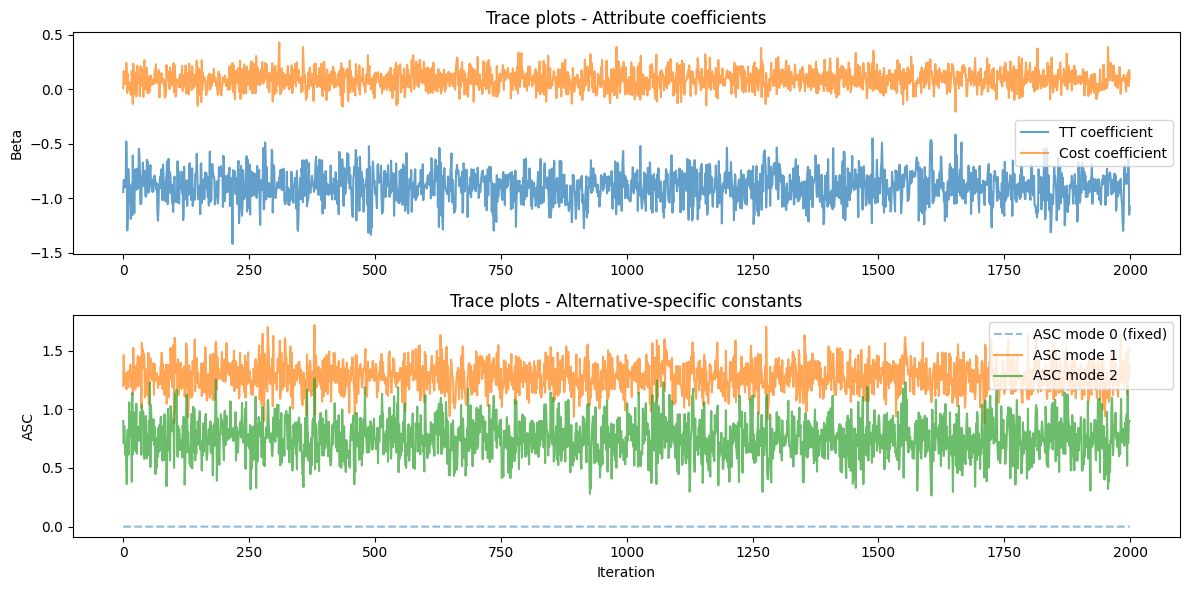

In [10]:
# Plot trace plots for diagnostics
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Beta (attribute effects)
beta_samples = posterior_samples['beta']
axes[0].plot(beta_samples[:, 0], label='TT coefficient', alpha=0.7)
axes[0].plot(beta_samples[:, 1], label='Cost coefficient', alpha=0.7)
axes[0].set_ylabel('Beta')
axes[0].legend()
axes[0].set_title('Trace plots - Attribute coefficients')

# ASC (alternative-specific constants) - only 2 sampled (first fixed to 0)
asc_samples = posterior_samples['asc']
axes[1].plot(torch.zeros_like(asc_samples[:, 0]), label='ASC mode 0 (fixed)', alpha=0.5, linestyle='--')
for i in range(asc_samples.shape[1]):
    axes[1].plot(asc_samples[:, i], label=f'ASC mode {i+1}', alpha=0.7)
axes[1].set_ylabel('ASC')
axes[1].set_xlabel('Iteration')
axes[1].legend()
axes[1].set_title('Trace plots - Alternative-specific constants')

plt.tight_layout()
plt.show()

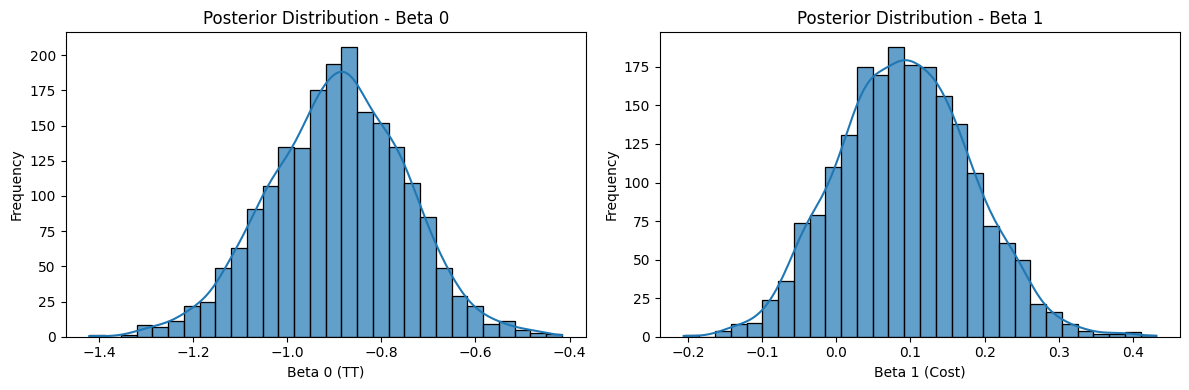

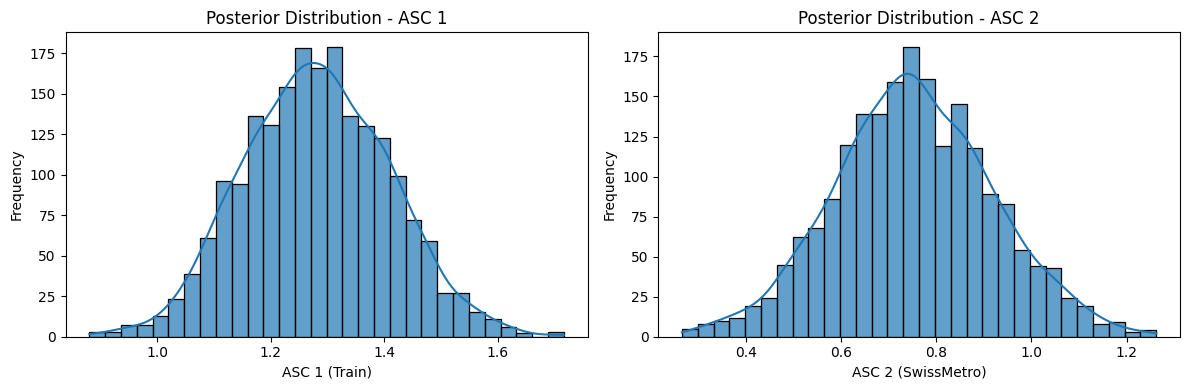

In [11]:
# Plot posterior distributions for beta (attribute coefficients)
fig, axes = plt.subplots(1, X.shape[1], figsize=(12, 4))

beta_samples = posterior_samples['beta'].detach().numpy()
for d in range(X.shape[1]):
    sns.histplot(beta_samples[:, d], bins=30, kde=True, alpha=0.7, ax=axes[d])
    axes[d].set_xlabel(f'Beta {d} ({"TT" if d==0 else "Cost"})')
    axes[d].set_ylabel('Frequency')
    axes[d].set_title(f'Posterior Distribution - Beta {d}')

plt.tight_layout()
plt.show()

# Plot posterior distributions for ASC (alternative-specific constants)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

asc_samples = posterior_samples['asc'].detach().numpy()
mode_names = ['Train', 'SwissMetro']

for c in range(asc_samples.shape[1]):
    sns.histplot(asc_samples[:, c], bins=30, kde=True, alpha=0.7, ax=axes[c])
    axes[c].set_xlabel(f'ASC {c+1} ({mode_names[c]})')
    axes[c].set_ylabel('Frequency')
    axes[c].set_title(f'Posterior Distribution - ASC {c+1}')

plt.tight_layout()
plt.show()

---
## Mixture of Logits — K latent classes, uniform weights

Extension of MNL with K sets of (β, ASC) parameters, marginalising over classes with equal weight 1/K per scenario.

In [12]:
n_obs_lccm = int(obs_id.max().item()) + 1

Y_wide = torch.zeros(n_obs_lccm, dtype=torch.int64)
chosen_mask = Y == 1
Y_wide[obs_id[chosen_mask]] = alt_id[chosen_mask]

print(f"Observations : {n_obs_lccm}")
print(f"Choice counts: {Y_wide.bincount()}")

Observations : 450
Choice counts: tensor([ 76, 275,  99])


In [13]:
def model_mixture(X, obs_id, alt_id, Y_wide, n_alts=3, K=2):
    """Mixture of Logits: K classes with uniform mixing weights, marginalised per scenario."""
    n_obs      = Y_wide.shape[0]
    n_features = X.shape[1]

    beta    = pyro.sample('beta', dist.Normal(0., 1.).expand([K, n_features]).to_event(2))
    asc_raw = pyro.sample('asc',  dist.Normal(0., 1.).expand([K, n_alts - 1]).to_event(2))
    asc_full = torch.cat([torch.zeros(K, 1), asc_raw], dim=1)  # Train ASC fixed to 0

    log_w = -torch.log(torch.tensor(float(K)))

    log_lik_list = []
    for k in range(K):
        V_k      = X @ beta[k] + asc_full[k][alt_id]
        V_wide_k = torch.full((n_obs, n_alts), -1e9)
        V_wide_k[obs_id, alt_id] = V_k
        log_lik_list.append(dist.Categorical(logits=V_wide_k).log_prob(Y_wide))

    log_lik      = torch.stack(log_lik_list, dim=1)         # [n_obs, K]
    log_marginal = torch.logsumexp(log_w + log_lik, dim=-1) # [n_obs]

    with pyro.plate('obs', n_obs):
        pyro.factor('loglik', log_marginal)

In [14]:
pyro.clear_param_store()

K = 2
nuts_kernel = NUTS(model_mixture, adapt_step_size=True)
mcmc_mix = MCMC(nuts_kernel, num_samples=500, warmup_steps=300, num_chains=1)
mcmc_mix.run(X, obs_id, alt_id, Y_wide, n_alts=3, K=K)

Sample: 100%|██████████| 800/800 [00:04, 169.55it/s, step size=3.86e-01, acc. prob=0.897]


### Inspect posterior — label-switching correction

Classes are exchangeable, so we sort by β_TT to ensure class 0 is always the more time-sensitive segment.

                                    mean      std
--------------------------------------------------

  Class 0:
    beta_TT      -1.742    0.337
    beta_CO       0.313    0.401
    ASC_SM        0.848    1.380
    ASC_Car       0.857    0.961

  Class 1:
    beta_TT      -1.150    0.358
    beta_CO       0.065    0.360
    ASC_SM        1.942    1.273
    ASC_Car       0.014    0.968


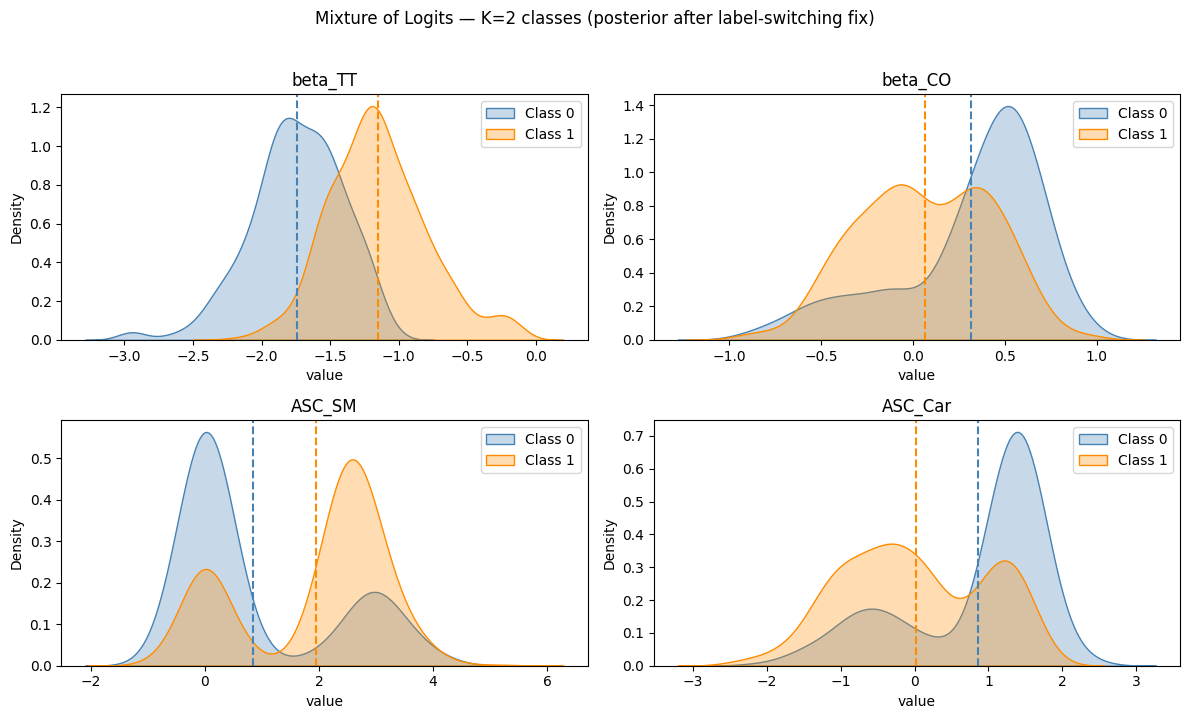

In [15]:
samples = mcmc_mix.get_samples()

beta_s = samples['beta']  # [S, K, 2]
asc_s  = samples['asc']   # [S, K, 2]

# sort by beta_TT so class 0 is always the more time-sensitive segment
order  = beta_s[:, :, 0].argsort(dim=1)
beta_s = torch.gather(beta_s, 1, order.unsqueeze(-1).expand_as(beta_s))
asc_s  = torch.gather(asc_s,  1, order.unsqueeze(-1).expand_as(asc_s))

print(f"{'':30s}  {'mean':>8}  {'std':>7}")
print("-" * 50)
for k in range(K):
    print(f"\n  Class {k}:")
    for f, fname in enumerate(['TT', 'CO']):
        m = beta_s[:, k, f].mean().item()
        s = beta_s[:, k, f].std().item()
        print(f"    beta_{fname:<4}  {m:>8.3f}  {s:>7.3f}")
    for a, aname in enumerate(['SM', 'Car']):
        m = asc_s[:, k, a].mean().item()
        s = asc_s[:, k, a].std().item()
        print(f"    ASC_{aname:<5}  {m:>8.3f}  {s:>7.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes   = axes.ravel()
colors = ['steelblue', 'darkorange']

params = [
    ('beta_TT', [beta_s[:, k, 0].numpy() for k in range(K)]),
    ('beta_CO', [beta_s[:, k, 1].numpy() for k in range(K)]),
    ('ASC_SM',  [asc_s[:,  k, 0].numpy() for k in range(K)]),
    ('ASC_Car', [asc_s[:,  k, 1].numpy() for k in range(K)]),
]

for ax, (pname, draws_list) in zip(axes, params):
    for k, draws in enumerate(draws_list):
        sns.kdeplot(draws, ax=ax, color=colors[k], label=f'Class {k}', fill=True, alpha=0.3)
        ax.axvline(draws.mean(), color=colors[k], linestyle='--', linewidth=1.5)
    ax.set_title(pname)
    ax.set_xlabel('value')
    ax.legend()

plt.suptitle(f'Mixture of Logits — K={K} classes (posterior after label-switching fix)', y=1.02)
plt.tight_layout()
plt.show()

---
## Mixture of Logits with SVI — full dataset

Switch from MCMC to Stochastic Variational Inference (SVI) with AutoNormal guide to scale to all 752 individuals.

In [16]:
df_full_raw = pd.read_csv('swissmetro.dat', sep='\t')

# Keep only observations with known age, explicit choices, and non-'other' trip purposes.
# In this file, AGE==6 is the unknown age code and PURPOSE==9 is 'other'.
valid_age_full = df_full_raw['AGE'].notna() & (df_full_raw['AGE'] != 6)
valid_choice_full = df_full_raw['CHOICE'] != 0
valid_purpose_full = df_full_raw['PURPOSE'] != 9
df_full_filtered = df_full_raw[valid_age_full & valid_choice_full & valid_purpose_full].copy()

print(f"Filtered dataset: {len(df_full_filtered)} observations, {df_full_filtered['ID'].nunique()} respondents")

# Reproducible 80/20 split at respondent level (panel-safe), using the seed value from the notebook start.
rng = np.random.default_rng(11)
all_ids = df_full_filtered['ID'].drop_duplicates().to_numpy()
shuffled_ids = rng.permutation(all_ids)
n_train_ids = int(0.8 * len(shuffled_ids))
train_ids = set(shuffled_ids[:n_train_ids])
test_ids = set(shuffled_ids[n_train_ids:])

df_full = df_full_filtered[df_full_filtered['ID'].isin(train_ids)].copy()
df_test = df_full_filtered[df_full_filtered['ID'].isin(test_ids)].copy()

print(f"Train split: {len(df_full)} observations, {df_full['ID'].nunique()} respondents")
print(f"Test split : {len(df_test)} observations, {df_test['ID'].nunique()} respondents")

# Standardize using train statistics and apply to both train and test.
for raw_col, scaled_col in [
    ('TRAIN_TT', 'TRAIN_TT_S'), ('TRAIN_CO', 'TRAIN_CO_S'),
    ('SM_TT',    'SM_TT_S'),    ('SM_CO',    'SM_CO_S'),
    ('CAR_TT',   'CAR_TT_S'),   ('CAR_CO',   'CAR_CO_S'),
]:
    mu = df_full[raw_col].mean()
    sig = df_full[raw_col].std()
    df_full[scaled_col] = (df_full[raw_col] - mu) / sig
    df_test[scaled_col] = (df_test[raw_col] - mu) / sig

long_rows = []
obs_map   = {orig: new for new, orig in enumerate(df_full.index.unique())}

alt_cfg = [
    (0, 'TRAIN_AV', 'TRAIN_TT_S', 'TRAIN_CO_S', 1),
    (1, 'SM_AV',    'SM_TT_S',    'SM_CO_S',    2),
    (2, 'CAR_AV',   'CAR_TT_S',   'CAR_CO_S',   3),
]
for idx, row in df_full.iterrows():
    oid = obs_map[idx]
    for alt, av, tt_col, co_col, choice_val in alt_cfg:
        if row[av] == 1:
            long_rows.append({
                'obs_id': oid, 'alt_id': alt,
                'tt': row[tt_col], 'co': row[co_col],
                'choice': 1 if row['CHOICE'] == choice_val else 0,
            })

long_full = pd.DataFrame(long_rows)
assert (long_full.groupby('obs_id')['choice'].sum() == 1).all(), "choice validation failed"

X_f      = torch.tensor(long_full[['tt', 'co']].values, dtype=torch.float32)
Y_f      = torch.tensor(long_full['choice'].values,      dtype=torch.int64)
obs_id_f = torch.tensor(long_full['obs_id'].values,      dtype=torch.int64)
alt_id_f = torch.tensor(long_full['alt_id'].values,      dtype=torch.int64)

n_obs_f    = int(obs_id_f.max().item()) + 1
Y_wide_f   = torch.zeros(n_obs_f, dtype=torch.int64)
mask_f     = Y_f == 1
Y_wide_f[obs_id_f[mask_f]] = alt_id_f[mask_f]

# Verify train tensors are based on the same filtered/split train scenarios.
assert n_obs_f == len(df_full), "Tensor basis check failed: n_obs_f does not match filtered train df_full."

print(f"Train observations used by model : {n_obs_f}")
print(f"Train long rows                 : {len(long_full)}")
print(f"Train choice counts (Train/SM/Car): {Y_wide_f.bincount().tolist()}")

Filtered dataset: 10692 observations, 1188 respondents
Train split: 8550 observations, 950 respondents
Test split : 2142 observations, 238 respondents
Train observations used by model : 8550
Train long rows                 : 24354
Train choice counts (Train/SM/Car): [1100, 4987, 2463]


[step    0]  ELBO loss: 8,905.7
[step  500]  ELBO loss: 6,930.1
[step 1000]  ELBO loss: 6,928.4
[step 1500]  ELBO loss: 6,930.1
[step 2000]  ELBO loss: 6,929.7
[step 2500]  ELBO loss: 6,935.6
[step 2999]  ELBO loss: 6,928.0


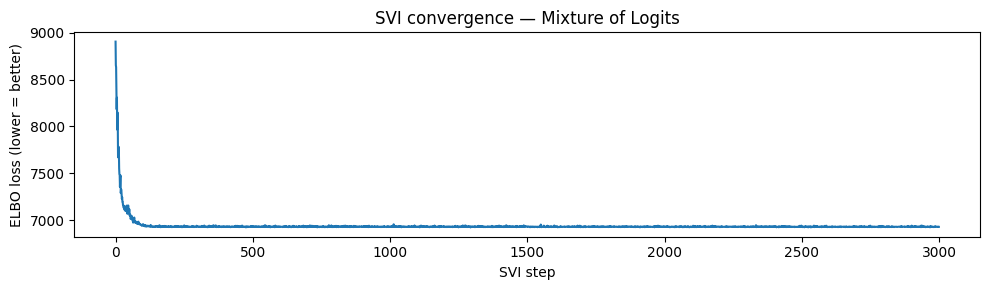

In [17]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoNormal
from pyro.optim import ClippedAdam

pyro.clear_param_store()
pyro.set_rng_seed(42)

K = 2

guide     = AutoNormal(model_mixture)
optimizer = ClippedAdam({"lr": 0.05, "lrd": 0.9995})
svi       = SVI(model_mixture, guide, optimizer, loss=Trace_ELBO())

n_steps = 3000
losses  = []

for step in range(n_steps):
    loss = svi.step(X_f, obs_id_f, alt_id_f, Y_wide_f, n_alts=3, K=K)
    losses.append(loss)
    if step % 500 == 0 or step == n_steps - 1:
        print(f"[step {step:4d}]  ELBO loss: {loss:,.1f}")

plt.figure(figsize=(10, 3))
plt.plot(losses)
plt.xlabel('SVI step')
plt.ylabel('ELBO loss (lower = better)')
plt.title('SVI convergence — Mixture of Logits')
plt.tight_layout()
plt.show()

                                    mean      std
--------------------------------------------------

  Class 0:
    beta_TT      -2.289    0.068
    beta_CO       0.470    0.047
    ASC_SM        0.026    0.061
    ASC_Car       1.807    0.049

  Class 1:
    beta_TT       0.265    0.085
    beta_CO      -0.189    0.092
    ASC_SM        3.547    0.144
    ASC_Car       0.269    0.218


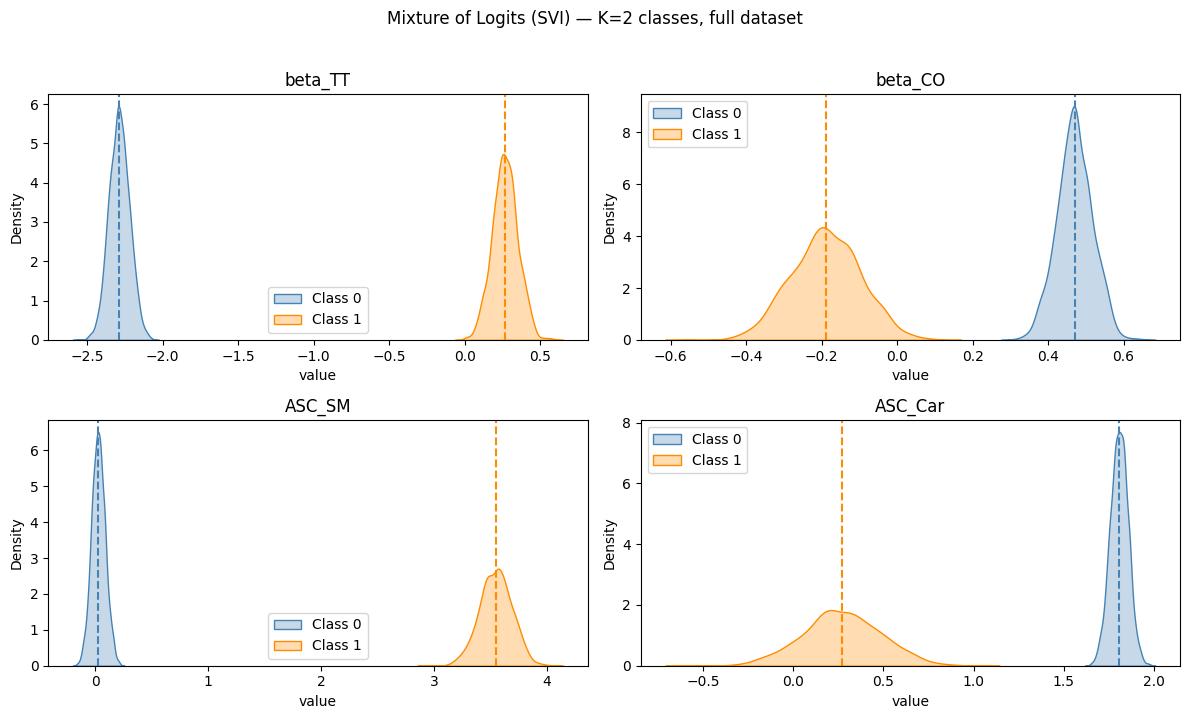

In [18]:
# Predictive() clashes with AutoNormal's K-class dimension, so we sample the guide directly
with torch.no_grad():
    beta_list, asc_list = [], []
    for _ in range(2000):
        s = guide(X_f, obs_id_f, alt_id_f, Y_wide_f, n_alts=3, K=K)
        beta_list.append(s['beta'])
        asc_list.append(s['asc'])

beta_s = torch.stack(beta_list)  # [2000, K, 2]
asc_s  = torch.stack(asc_list)   # [2000, K, 2]

order  = beta_s[:, :, 0].argsort(dim=1)
beta_s = torch.gather(beta_s, 1, order.unsqueeze(-1).expand_as(beta_s))
asc_s  = torch.gather(asc_s,  1, order.unsqueeze(-1).expand_as(asc_s))

print(f"{'':30s}  {'mean':>8}  {'std':>7}")
print("-" * 50)
for k in range(K):
    print(f"\n  Class {k}:")
    for f, fname in enumerate(['TT', 'CO']):
        m = beta_s[:, k, f].mean().item()
        s = beta_s[:, k, f].std().item()
        print(f"    beta_{fname:<4}  {m:>8.3f}  {s:>7.3f}")
    for a, aname in enumerate(['SM', 'Car']):
        m = asc_s[:, k, a].mean().item()
        s = asc_s[:, k, a].std().item()
        print(f"    ASC_{aname:<5}  {m:>8.3f}  {s:>7.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes   = axes.ravel()
colors = ['steelblue', 'darkorange']

params = [
    ('beta_TT', [beta_s[:, k, 0].numpy() for k in range(K)]),
    ('beta_CO', [beta_s[:, k, 1].numpy() for k in range(K)]),
    ('ASC_SM',  [asc_s[:,  k, 0].numpy() for k in range(K)]),
    ('ASC_Car', [asc_s[:,  k, 1].numpy() for k in range(K)]),
]

for ax, (pname, draws_list) in zip(axes, params):
    for k, draws in enumerate(draws_list):
        sns.kdeplot(draws, ax=ax, color=colors[k], label=f'Class {k}', fill=True, alpha=0.3)
        ax.axvline(draws.mean(), color=colors[k], linestyle='--', linewidth=1.5)
    ax.set_title(pname)
    ax.set_xlabel('value')
    ax.legend()

plt.suptitle(f'Mixture of Logits (SVI) — K={K} classes, full dataset', y=1.02)
plt.tight_layout()
plt.show()

---
## LCCM — Person-level Latent Class with Learnable Mixing Weights

Class membership is assigned at the person level by summing all 9 scenario log-likelihoods per person before the logsumexp, with mixing weights π learned via a Dirichlet prior.

In [19]:
person_seq  = {pid: i for i, pid in enumerate(df_full['ID'].unique())}
rev_obs_map = {v: k for k, v in obs_map.items()}

person_obs_id_f = torch.tensor(
    [person_seq[df_full.loc[rev_obs_map[t], 'ID']] for t in range(n_obs_f)],
    dtype=torch.int64,
)

n_persons_f = int(person_obs_id_f.max().item()) + 1
print(f"Persons: {n_persons_f},  Scenarios: {n_obs_f},  Ratio: {n_obs_f/n_persons_f:.1f}")

assert (person_obs_id_f.bincount() == 9).all()
print(f"✓ All {n_persons_f} persons have exactly 9 scenarios")

Persons: 950,  Scenarios: 8550,  Ratio: 9.0
✓ All 950 persons have exactly 9 scenarios


In [20]:
def model_lccm(X, obs_id, alt_id, Y_wide, person_obs_id, n_alts=3, K=2):
    """Bayesian LCCM (Sfeir et al. 2021, Eq. 6-9): person-level class membership, learnable π."""
    n_persons   = int(person_obs_id.max().item()) + 1
    n_scenarios = Y_wide.shape[0]
    n_features  = X.shape[1]

    pi    = pyro.sample('pi', dist.Dirichlet(torch.ones(K)))
    log_w = pi.log()

    beta    = pyro.sample('beta', dist.Normal(0., 1.).expand([K, n_features]).to_event(2))
    asc_raw = pyro.sample('asc',  dist.Normal(0., 1.).expand([K, n_alts - 1]).to_event(2))
    asc_full = torch.cat([torch.zeros(K, 1), asc_raw], dim=1)  # Train ASC fixed to 0

    scen_ll_list = []
    for k in range(K):
        V_k      = X @ beta[k] + asc_full[k][alt_id]
        V_wide_k = torch.full((n_scenarios, n_alts), -1e9)
        V_wide_k[obs_id, alt_id] = V_k
        scen_ll_list.append(dist.Categorical(logits=V_wide_k).log_prob(Y_wide))

    scen_ll = torch.stack(scen_ll_list, dim=1)  # [n_scenarios, K]

    # sum each person's 9 scenario log-probs before the logsumexp (person-level membership)
    person_ll = torch.zeros(n_persons, K)
    person_ll.scatter_add_(0, person_obs_id.unsqueeze(1).expand_as(scen_ll), scen_ll)

    log_marginal = torch.logsumexp(log_w + person_ll, dim=-1)  # [n_persons]

    with pyro.plate('persons', n_persons):
        pyro.factor('loglik', log_marginal)

[step    0]  ELBO loss: 8,629.4
[step  500]  ELBO loss: 6,199.3
[step 1000]  ELBO loss: 6,198.1
[step 1500]  ELBO loss: 6,194.3
[step 2000]  ELBO loss: 6,195.4
[step 2500]  ELBO loss: 6,192.2
[step 2999]  ELBO loss: 6,196.9


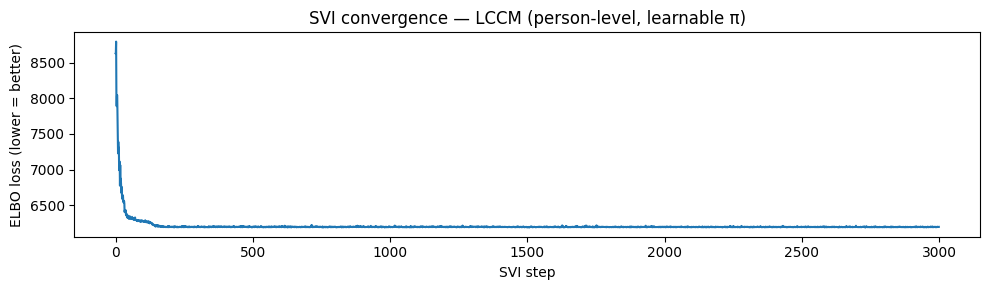

In [21]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoNormal
from pyro.optim import ClippedAdam

pyro.clear_param_store()
pyro.set_rng_seed(42)
K = 2

guide_lccm = AutoNormal(model_lccm)
optimizer  = ClippedAdam({"lr": 0.05, "lrd": 0.9995})
svi_lccm   = SVI(model_lccm, guide_lccm, optimizer, loss=Trace_ELBO())

n_steps = 3000
losses_lccm = []

for step in range(n_steps):
    loss = svi_lccm.step(X_f, obs_id_f, alt_id_f, Y_wide_f, person_obs_id_f, n_alts=3, K=K)
    losses_lccm.append(loss)
    if step % 500 == 0 or step == n_steps - 1:
        print(f"[step {step:4d}]  ELBO loss: {loss:,.1f}")

plt.figure(figsize=(10, 3))
plt.plot(losses_lccm)
plt.xlabel('SVI step')
plt.ylabel('ELBO loss (lower = better)')
plt.title('SVI convergence — LCCM (person-level, learnable π)')
plt.tight_layout()
plt.show()

                                    mean      std
--------------------------------------------------

  Class 0  (π: 0.477 ± 0.022):
    beta_TT      -1.274    0.065
    beta_CO       0.276    0.055
    ASC_SM        0.565    0.726
    ASC_Car       1.424    0.046

  Class 1  (π: 0.523 ± 0.022):
    beta_TT      -1.136    0.062
    beta_CO       0.138    0.058
    ASC_SM        2.887    0.726
    ASC_Car       1.382    0.064


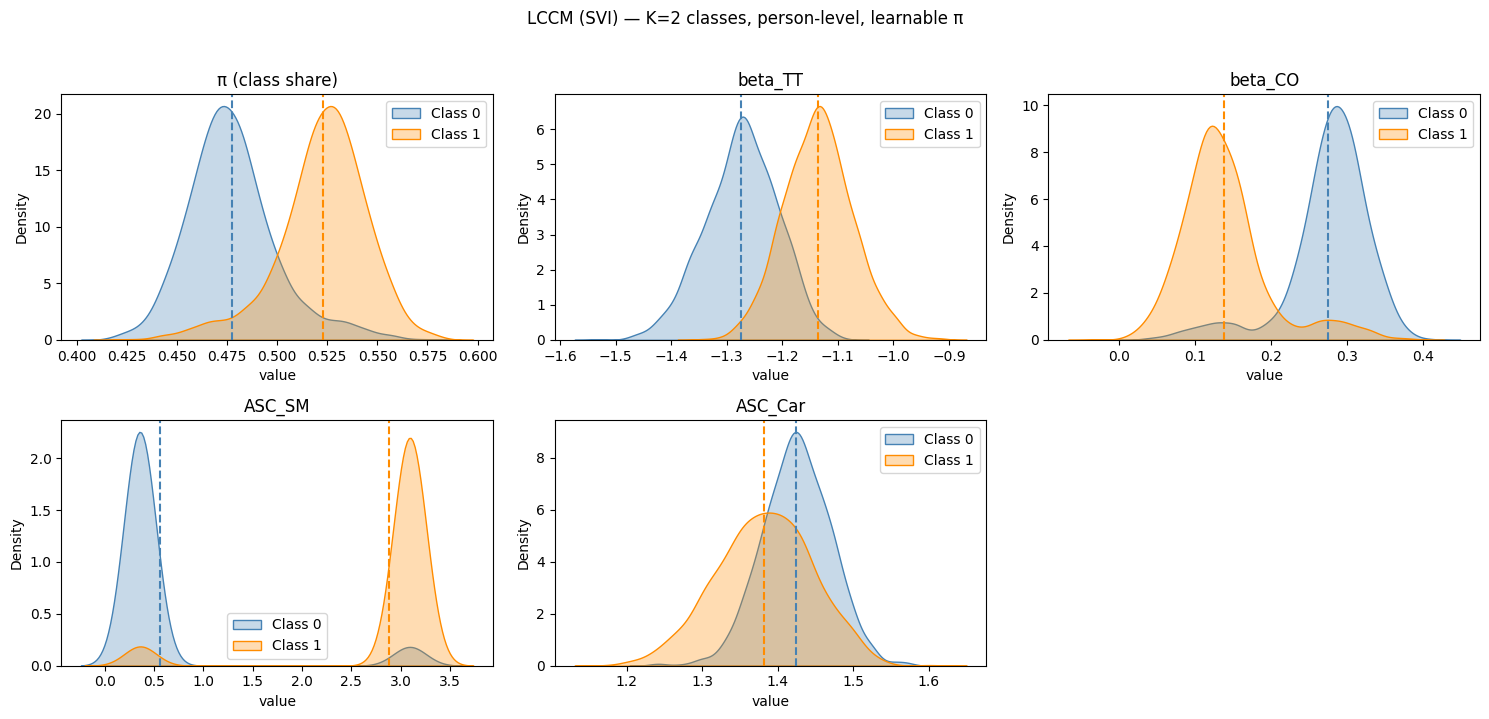

In [22]:
with torch.no_grad():
    pi_list, beta_list, asc_list = [], [], []
    for _ in range(2000):
        s = guide_lccm(X_f, obs_id_f, alt_id_f, Y_wide_f, person_obs_id_f, n_alts=3, K=K)
        pi_list.append(s['pi'])
        beta_list.append(s['beta'])
        asc_list.append(s['asc'])

pi_s   = torch.stack(pi_list)    # [2000, K]
beta_s = torch.stack(beta_list)  # [2000, K, 2]
asc_s  = torch.stack(asc_list)   # [2000, K, 2]

order  = beta_s[:, :, 0].argsort(dim=1)
beta_s = torch.gather(beta_s, 1, order.unsqueeze(-1).expand_as(beta_s))
asc_s  = torch.gather(asc_s,  1, order.unsqueeze(-1).expand_as(asc_s))
pi_s   = torch.gather(pi_s,   1, order)

print(f"{'':30s}  {'mean':>8}  {'std':>7}")
print("-" * 50)
for k in range(K):
    print(f"\n  Class {k}  (π: {pi_s[:, k].mean():.3f} ± {pi_s[:, k].std():.3f}):")
    for f, fname in enumerate(['TT', 'CO']):
        m = beta_s[:, k, f].mean().item()
        s = beta_s[:, k, f].std().item()
        print(f"    beta_{fname:<4}  {m:>8.3f}  {s:>7.3f}")
    for a, aname in enumerate(['SM', 'Car']):
        m = asc_s[:, k, a].mean().item()
        s = asc_s[:, k, a].std().item()
        print(f"    ASC_{aname:<5}  {m:>8.3f}  {s:>7.3f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
colors = ['steelblue', 'darkorange']

params = [
    ('π (class share)',  [pi_s[:,   k].numpy() for k in range(K)]),
    ('beta_TT',          [beta_s[:, k, 0].numpy() for k in range(K)]),
    ('beta_CO',          [beta_s[:, k, 1].numpy() for k in range(K)]),
    ('ASC_SM',           [asc_s[:,  k, 0].numpy() for k in range(K)]),
    ('ASC_Car',          [asc_s[:,  k, 1].numpy() for k in range(K)]),
]

for ax, (pname, draws_list) in zip(axes.ravel()[:5], params):
    for k, draws in enumerate(draws_list):
        sns.kdeplot(draws, ax=ax, color=colors[k], label=f'Class {k}', fill=True, alpha=0.3)
        ax.axvline(draws.mean(), color=colors[k], linestyle='--', linewidth=1.5)
    ax.set_title(pname)
    ax.set_xlabel('value')
    ax.legend()

axes.ravel()[-1].set_visible(False)

plt.suptitle(f'LCCM (SVI) — K={K} classes, person-level, learnable π', y=1.02)
plt.tight_layout()
plt.show()

### Compare K = 2 to 7 on train and test

In [25]:
import pyro.optim

n_obs = int(obs_id.max().item()) + 1
person_obs_id = torch.tensor(pd.factorize(df['ID'])[0], dtype=torch.int64)
n_persons = int(person_obs_id.max().item()) + 1

assert long_df['obs_id'].nunique() == len(df), 'test long-format observation mismatch'
assert (person_obs_id.bincount() == 9).all(), 'each test person should have 9 scenarios'

K_values = range(2, 8)
comparison_rows = []
posterior_draws_by_k = {}

for K_value in K_values:
    pyro.clear_param_store()
    guide = AutoNormal(model_lccm)
    optimizer = pyro.optim.ClippedAdam({'lr': 0.05, 'lrd': 0.9995})
    svi = SVI(model_lccm, guide, optimizer, loss=Trace_ELBO())

    for step in range(1200):
        loss = svi.step(X_f, obs_id_f, alt_id_f, Y_wide_f, person_obs_id_f, n_alts=3, K=K_value)
        if step % 300 == 0 or step == 1199:
            print(f'[K={K_value}] step {step:4d}  ELBO loss: {loss:,.1f}')

    beta_draws = []
    asc_draws = []
    pi_draws = []
    with torch.no_grad():
        for _ in range(300):
            sample = guide(X_f, obs_id_f, alt_id_f, Y_wide_f, person_obs_id_f, n_alts=3, K=K_value)
            beta_draws.append(sample['beta'])
            asc_draws.append(sample['asc'])
            pi_draws.append(sample['pi'])

    beta_s = torch.stack(beta_draws)
    asc_s = torch.stack(asc_draws)
    pi_s = torch.stack(pi_draws)
    posterior_draws_by_k[K_value] = {'beta_s': beta_s.detach().clone(), 'asc_s': asc_s.detach().clone()}

    beta_mean = beta_s.mean(dim=0)
    asc_mean = asc_s.mean(dim=0)
    asc_full_mean = torch.cat([torch.zeros(K_value, 1, dtype=asc_mean.dtype, device=asc_mean.device), asc_mean], dim=1)
    pi_mean = pi_s.mean(dim=0)
    pi_mean = pi_mean / pi_mean.sum()

    class_ll = []
    for k in range(K_value):
        V_k = X_f @ beta_mean[k] + asc_full_mean[k][alt_id_f]
        V_wide_k = torch.full((n_obs_f, 3), -1e9)
        V_wide_k[obs_id_f, alt_id_f] = V_k
        class_ll.append(dist.Categorical(logits=V_wide_k).log_prob(Y_wide_f))

    scen_ll = torch.stack(class_ll, dim=1)
    person_ll = torch.zeros(int(person_obs_id_f.max().item()) + 1, K_value)
    person_ll.scatter_add_(0, person_obs_id_f.unsqueeze(1).expand_as(scen_ll), scen_ll)
    train_ll = torch.logsumexp(torch.log(pi_mean) + person_ll, dim=-1).sum().item()

    test_draw_ll = []
    with torch.no_grad():
        asc_full_s = torch.cat([torch.zeros(asc_s.shape[0], K_value, 1, dtype=asc_s.dtype, device=asc_s.device), asc_s], dim=2)
        for i in range(beta_s.shape[0]):
            class_ll = []
            for k in range(K_value):
                V_k = X @ beta_s[i, k] + asc_full_s[i, k][alt_id]
                V_wide_k = torch.full((n_obs, 3), -1e9)
                V_wide_k[obs_id, alt_id] = V_k
                class_ll.append(dist.Categorical(logits=V_wide_k).log_prob(Y_wide))
            scen_ll = torch.stack(class_ll, dim=1)
            person_ll = torch.zeros(n_persons, K_value)
            person_ll.scatter_add_(0, person_obs_id.unsqueeze(1).expand_as(scen_ll), scen_ll)
            test_draw_ll.append(torch.logsumexp(torch.log(pi_s[i] / pi_s[i].sum()) + person_ll, dim=-1).sum())

    test_pred_ll = (torch.logsumexp(torch.stack(test_draw_ll), dim=0) - np.log(len(test_draw_ll))).item()

    n_params = K_value * X_f.shape[1] + K_value * (3 - 1) + (K_value - 1)
    aic = 2 * n_params - 2 * train_ll
    bic = np.log(int(person_obs_id_f.max().item()) + 1) * n_params - 2 * train_ll

    comparison_rows.append({
        'K': K_value,
        'n_params': n_params,
        'train_ll': train_ll,
        'test_pred_ll': test_pred_ll,
        'AIC': aic,
        'BIC': bic,
    })


[K=2] step    0  ELBO loss: 8,694.3
[K=2] step  300  ELBO loss: 6,190.9
[K=2] step  600  ELBO loss: 6,196.3
[K=2] step  900  ELBO loss: 6,192.7
[K=2] step 1199  ELBO loss: 6,193.7
[K=3] step    0  ELBO loss: 8,983.7
[K=3] step  300  ELBO loss: 5,544.8
[K=3] step  600  ELBO loss: 5,543.8
[K=3] step  900  ELBO loss: 5,557.2
[K=3] step 1199  ELBO loss: 5,549.2
[K=4] step    0  ELBO loss: 8,663.4
[K=4] step  300  ELBO loss: 5,389.9
[K=4] step  600  ELBO loss: 5,362.2
[K=4] step  900  ELBO loss: 5,377.3
[K=4] step 1199  ELBO loss: 5,365.4
[K=5] step    0  ELBO loss: 8,801.6
[K=5] step  300  ELBO loss: 5,401.9
[K=5] step  600  ELBO loss: 5,349.3
[K=5] step  900  ELBO loss: 5,350.5
[K=5] step 1199  ELBO loss: 5,342.8
[K=6] step    0  ELBO loss: 8,777.7
[K=6] step  300  ELBO loss: 5,280.7
[K=6] step  600  ELBO loss: 5,268.4
[K=6] step  900  ELBO loss: 5,268.8
[K=6] step 1199  ELBO loss: 5,270.2
[K=7] step    0  ELBO loss: 8,911.5
[K=7] step  300  ELBO loss: 5,265.8
[K=7] step  600  ELBO loss: 

In [26]:
comparison_df = pd.DataFrame(comparison_rows).sort_values('K').reset_index(drop=True)
print('\nModel comparison table:')
print(comparison_df.to_string(index=False))

best_test_row = comparison_df.loc[comparison_df['test_pred_ll'].idxmax()]
print(f"\nBest test predictive LL: K={int(best_test_row['K'])} (test_pred_ll={best_test_row['test_pred_ll']:.2f})")


Model comparison table:
 K  n_params     train_ll  test_pred_ll          AIC          BIC
 2         9 -6159.824219   -319.396210 12337.648438 12381.356595
 3        14 -5485.788086   -290.987122 10999.576172 11067.566640
 4        19 -5278.724609   -282.999298 10595.449219 10687.721996
 5        24 -5239.431641   -279.214813 10526.863281 10643.418369
 6        29 -5131.518555   -271.652588 10321.037109 10461.874507
 7        34 -5101.367188   -271.844360 10270.734375 10435.854082

Best test predictive LL: K=6 (test_pred_ll=-271.65)


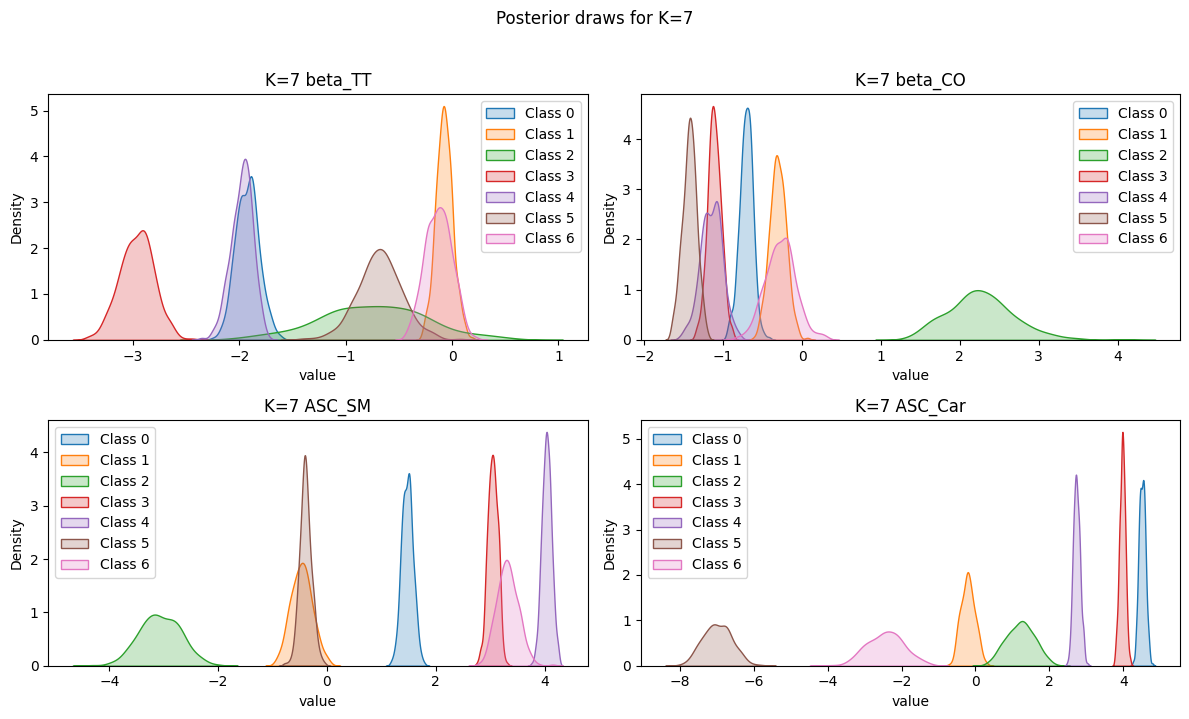

In [ ]:
K_plot = 7
draws = posterior_draws_by_k[K_plot]
beta_s_plot = draws['beta_s']
asc_s_plot = draws['asc_s']

# Plot posterior draws for the selected K
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()
plot_specs = [
    ('beta_TT', beta_s_plot[:, :, 0].detach().numpy()),
    ('beta_CO', beta_s_plot[:, :, 1].detach().numpy()),
    ('ASC_SM', asc_s_plot[:, :, 0].detach().numpy()),
    ('ASC_Car', asc_s_plot[:, :, 1].detach().numpy()),
]

for ax, (title, draws) in zip(axes, plot_specs):
    for k in range(draws.shape[1]):
        sns.kdeplot(draws[:, k], ax=ax, fill=True, alpha=0.25, label=f'Class {k}')
    ax.set_title(f'K={K_plot} {title}')
    ax.set_xlabel('value')
    ax.legend()

plt.suptitle(f'Posterior draws for K={K_plot}', y=1.02)
plt.tight_layout()
plt.show()